In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install xarray

In [ ]:
import os
import tarfile
import shutil
import numpy as np
import xarray as xr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.ndimage import zoom
from skimage.transform import resize
import tensorflow as tf

In [ ]:
backup_folder = "/content/drive/My Drive/TorNet_Backup"
target_folder = "/content/tornet_data"
output_file = "/content/processed_data.npz"
target_shape = (256, 256)
dbz_value_range = (-10, 75)
vel_value_range = (-50, 50)
os.environ['TORNET_ROOT'] = target_folder

os.makedirs(target_folder, exist_ok=True)

# Global variable to store all processed data
global_all_processed_data = np.empty((0, 120, 240, 2), dtype=np.float32)  # Stores processed data globally
global_all_labels = np.empty((0,), dtype=np.object_)          # Stores labels globally

global_all_processed_data_np = np.empty((0, 120, 240, 2), dtype=np.float32)
global_all_labels_np = np.empty((0,), dtype=np.object_)

def normalize_values(data, value_range):
    """Normalize data to the range [0, 1] based on specified value_range."""
    return (data - value_range[0]) / (value_range[1] - value_range[0])

def process_and_append(file, dbz_value_range, vel_value_range):
    """Process a single file and extract radar slices and labels."""
    ds = xr.open_dataset(file)

    processed_data = []
    labels = []

    # Extract DBZ and VEL (time, sweep, azimuth, range)
    dbz_data = ds['DBZ'].values  # Shape: (time, sweep, azimuth, range)
    vel_data = ds['VEL'].values  # Shape: (time, sweep, azimuth, range)

    # Handle NaN values
    dbz_data = np.nan_to_num(dbz_data, nan=0)
    vel_data = np.nan_to_num(vel_data, nan=0)

    # Convert azimuth from degrees to radians
    # azimuths = ds['azimuth'].values  # Azimuth (angles in degrees)
    # ranges = ds['range'].values     # Range (distances in meters)
    # azimuths_rad = np.deg2rad(azimuths)

    # Create meshgrid of azimuth and range
    # r, theta = np.meshgrid(ranges, azimuths_rad)

    # # Convert polar to Cartesian coordinates
    # x = r * np.sin(theta)
    # y = r * np.cos(theta)

    # Loop through each time and sweep combination
    for t in range(dbz_data.shape[0]):  # Iterate over time
            dbz_slice = dbz_data[t, :, :, 0]  # (azimuth, range)
            vel_slice = vel_data[t, :, :, 0]  # (azimuth, range)

            dbz_normalized = normalize_values(dbz_slice, dbz_value_range)
            vel_normalized = normalize_values(vel_slice, vel_value_range)

            # Stack DBZ and VEL along the last axis
            combined_slice = np.stack([dbz_normalized, vel_normalized], axis=-1)  # Shape: (azimuth, range, 2)
            processed_data.append(combined_slice)

            # Ensure the shapes are (azimuth, range) for both dbz_slice and vel_slice
            # print(f"dbz_normalized shape: {dbz_normalized.shape}, vel_normalized shape: {vel_normalized.shape}")

            # dbz_resized = resize_grid(dbz_normalized, target_shape)
            # vel_resized = resize_grid(vel_normalized, target_shape)

    # Get the category label
    category = ds.attrs['category']
    labels.extend([category] * len(processed_data))

    return np.array(processed_data), labels

def extract_and_process_from_drive(backup_folder, target_folder, output_file, dbz_value_range, vel_value_range):
    global global_all_processed_data, global_all_labels, global_all_processed_data_np, global_all_labels_np
    all_processed_data = []
    all_labels = []

    tar_files = [f for f in os.listdir(backup_folder) if f.endswith('.tar.gz')]

    test_tar_files = ['tornet_2013.tar.gz']

    for tar_file in test_tar_files:
      source_path = os.path.join(backup_folder, tar_file)
      local_tar_path = os.path.join(target_folder, tar_file)

      print(f"Restoring {tar_file} from Google Drive to {target_folder}...")
      shutil.copy(source_path, local_tar_path)

      print(f"Extracting {local_tar_path}...")
      with tarfile.open(local_tar_path, 'r:gz') as tar:
          tar.extractall(target_folder)

      print(f"Deleting {local_tar_path} to save space.")
      os.remove(local_tar_path)

      for subfolder in ["train"]:
        year_dir = os.path.join(target_folder, subfolder, tar_file.split('.')[0].replace("tornet_", ""))
        print(f"Processing files in {year_dir}...")
        if os.path.exists(year_dir):
          files = [os.path.join(year_dir, f) for f in os.listdir(year_dir) if f.endswith('.nc')]

          for file in files:
            processed_data, labels = process_and_append(file, dbz_value_range, vel_value_range)
            all_processed_data.extend(processed_data)
            all_labels.extend(labels)

          # Clear the processed year's directory to save space
          shutil.rmtree(year_dir)
          print(f"Cleared processed directory: {year_dir}")

      # Save all processed data and labels to a single file
      # global_all_processed_data = np.array(all_processed_data, dtype=np.float32)
      # global_all_labels = np.array(all_labels)

      if global_all_processed_data_np.size == 0:
        global_all_processed_data_np = np.array(all_processed_data)
      else:
        global_all_processed_data_np = np.concatenate([global_all_processed_data_np, all_processed_data], axis=0)

      global_all_labels_np = np.concatenate([global_all_labels_np, all_labels], axis=0)

      for subfolder in ["test"]:
        year_dir = os.path.join(target_folder, subfolder, tar_file.split('.')[0].replace("tornet_", ""))
        print(f"Processing files in {year_dir}...")
        if os.path.exists(year_dir):
          files = [os.path.join(year_dir, f) for f in os.listdir(year_dir) if f.endswith('.nc')]

          for file in files:
            processed_data, labels = process_and_append(file, dbz_value_range, vel_value_range)
            all_processed_data.extend(processed_data)
            all_labels.extend(labels)

          # Clear the processed year's directory to save space
          shutil.rmtree(year_dir)
          print(f"Cleared processed directory: {year_dir}")

      # Save all processed data and labels to a single file
      # global_all_processed_data = np.array(all_processed_data, dtype=np.float32)
      # global_all_labels = np.array(all_labels)

      if global_all_processed_data_np.size == 0:
        global_all_processed_data_np = np.array(all_processed_data)
      else:
        global_all_processed_data_np = np.concatenate([global_all_processed_data_np, all_processed_data], axis=0)

      global_all_labels_np = np.concatenate([global_all_labels_np, all_labels], axis=0)


    # np.savez_compressed(output_file, data=global_all_processed_data_np, labels=global_all_labels_np)
    # print(f"All data saved to {output_file}")

extract_and_process_from_drive(backup_folder, target_folder, output_file, dbz_value_range, vel_value_range)

print("Data")
print("Shape:", global_all_processed_data_np.shape)
print("Size:", global_all_processed_data_np.size)
print("Data type:", global_all_processed_data_np.dtype)
print("Number of dimensions:", global_all_processed_data_np.ndim)
print("Item size (bytes):", global_all_processed_data_np.itemsize)


print("Labels")
print("Shape:", global_all_labels_np.shape)
print("Size:", global_all_labels_np.size)
print("Data type:", global_all_labels_np.dtype)
print("Number of dimensions:", global_all_labels_np.ndim)
print("Item size (bytes):", global_all_labels_np.itemsize)

Restoring tornet_2013.tar.gz from Google Drive to /content/tornet_data...
Extracting /content/tornet_data/tornet_2013.tar.gz...
Deleting /content/tornet_data/tornet_2013.tar.gz to save space.
Processing files in /content/tornet_data/train/2013...
Cleared processed directory: /content/tornet_data/train/2013
Processing files in /content/tornet_data/test/2013...
Cleared processed directory: /content/tornet_data/test/2013
Data
Shape: (30276, 120, 240, 2)
Size: 1743897600
Data type: float32
Number of dimensions: 4
Item size (bytes): 4
Labels
Shape: (30276,)
Size: 30276
Data type: object
Number of dimensions: 1
Item size (bytes): 8


In [ ]:
from sklearn.model_selection import train_test_split

# Encode labels ('TOR'/'WRN' = 1, 'NUL' = 0)
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(global_all_labels_np != 'NUL')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    global_all_processed_data_np,
    labels_encoded,
    test_size=0.2,  # 20% for testing, adjust as needed
    random_state=42,  # Ensures reproducibility
    stratify=global_all_labels_np  # Keeps class proportions the same in train/test
)

# Ensure input data is normalized and reshaped
X_train = X_train.reshape(-1, 120, 240, 2)  # Radar slices with 2 channels
X_test = X_test.reshape(-1, 120, 240, 2)

# Check the shapes of the resulting splits
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (24220, 120, 240, 2)
X_test shape: (6056, 120, 240, 2)
y_train shape: (24220,)
y_test shape: (6056,)


Epoch 1/50
757/757 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - Precision: 0.4793 - Recall: 0.7791 - accuracy: 0.6838 - loss: 0.6151 - val_Precision: 0.7455 - val_Recall: 0.9268 - val_accuracy: 0.8857 - val_loss: 0.3103
Epoch 2/50
757/757 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - Precision: 0.6588 - Recall: 0.9133 - accuracy: 0.8341 - loss: 0.3458 - val_Precision: 0.7714 - val_Recall: 0.9690 - val_accuracy: 0.9067 - val_loss: 0.2608
Epoch 3/50
757/757 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - Precision: 0.7518 - Recall: 0.9524 - accuracy: 0.8935 - loss: 0.2342 - val_Precision: 0.8474 - val_Recall: 0.9752 - val_accuracy: 0.9412 - val_loss: 0.1797
Epoch 4/50
757/757 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - Precision: 0.8320 - Recall: 0.9676 - accuracy: 0.9334 - loss: 0.1640 - val_Precision: 0.9350 - val_Recall: 0.9724 - val_accuracy: 0.9721 - val_loss: 0.1004
Epoch 5/50
757/757 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - Precision: 0.8886 - Recall: 0.9800 - accuracy: 0.9582 - loss: 0.1186 - val_Precision: 0.9355 - val_Recal

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 118, 238, 32)        │             608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 59, 119, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 59, 119, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 57, 117, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 28, 58, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 28, 58, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 26, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 13, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 46592)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       5,963,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,198,885 (69.42 MB)

 Trainable params: 6,066,017 (23.14 MB)

 Non-trainable params: 832 (3.25 KB)

 Optimizer params: 12,132,036 (46.28 MB)

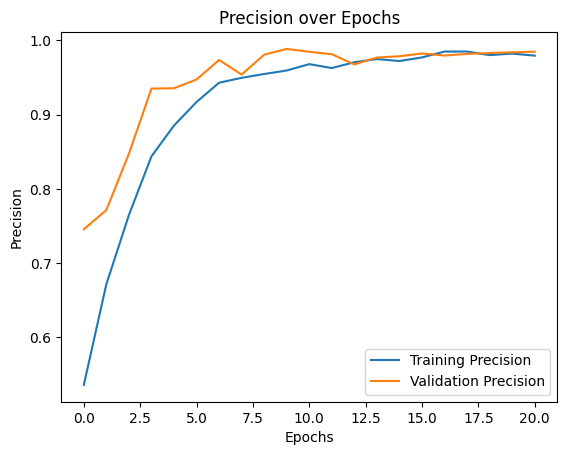

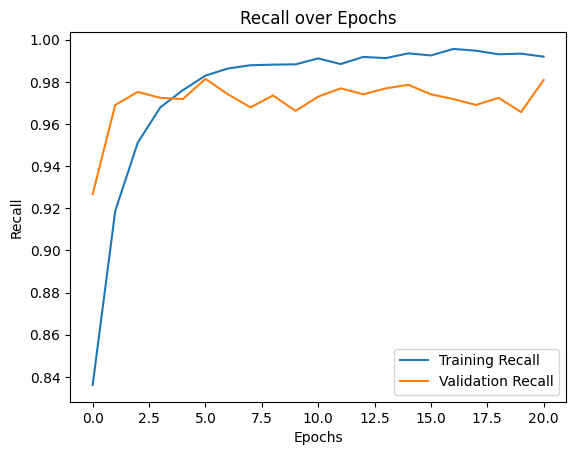

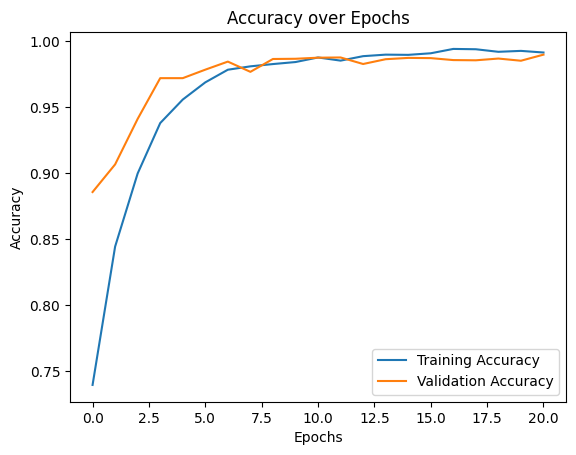

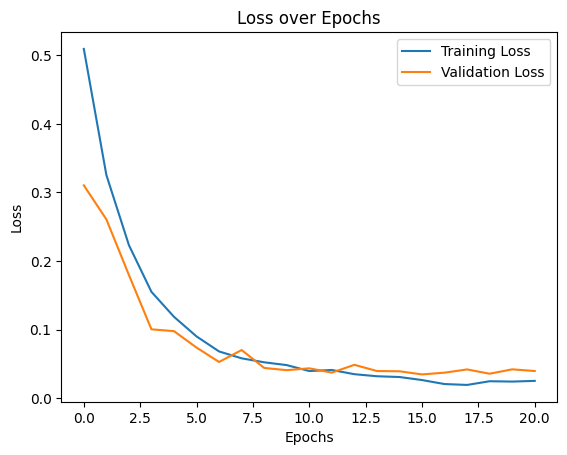

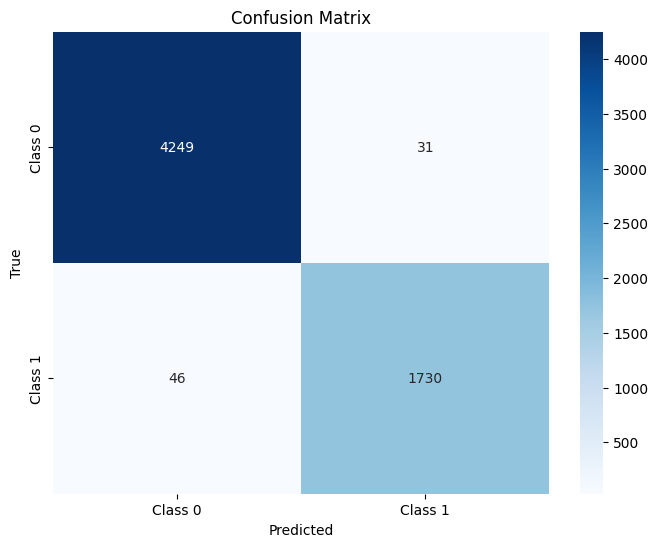

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute class weights
classes = np.array([0, 1])  # Convert to a NumPy array
class_weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)

# Convert class_weights to a dictionary format for the fit method
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Updated CNN model with Input layer
model = Sequential([
    layers.Input(shape=(120, 240, 2)),  # Explicit Input layer
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.00005),
              loss='binary_crossentropy',
              metrics=['accuracy', 'Precision', 'Recall'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test),
          class_weight=class_weight_dict, callbacks=[early_stopping])

# Evaluate and predict
# Evaluate and predict
evaluation_results = model.evaluate(X_test, y_test)
test_loss = evaluation_results[0]
test_acc = evaluation_results[1]
test_precision = evaluation_results[2]
test_recall = evaluation_results[3]

print(f"Test accuracy: {test_acc:.2f}")
print(f"Test precision: {test_precision:.2f}")
print(f"Test recall: {test_recall:.2f}")

y_pred = (model.predict(X_test) > 0.5).astype(int)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

model.summary()

# Plot training & validation precision values
plt.plot(history.history['Precision'], label='Training Precision')
plt.plot(history.history['val_Precision'], label='Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.title('Precision over Epochs')
plt.legend()
plt.show()

# Plot training & validation recall values
plt.plot(history.history['Recall'], label='Training Recall')
plt.plot(history.history['val_Recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Recall over Epochs')
plt.legend()
plt.show()

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

# Identify the epoch where early stopping stopped training
stopped_epoch = len(history.history['loss'])

# Annotate the epoch in the loss plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Non-Tornadic', 'Predicted Tornadic'], yticklabels=['Non-Tornadic', 'Tornadic'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(history.history.keys())

dict_keys(['Precision', 'Recall', 'accuracy', 'loss', 'val_Precision', 'val_Recall', 'val_accuracy', 'val_loss'])


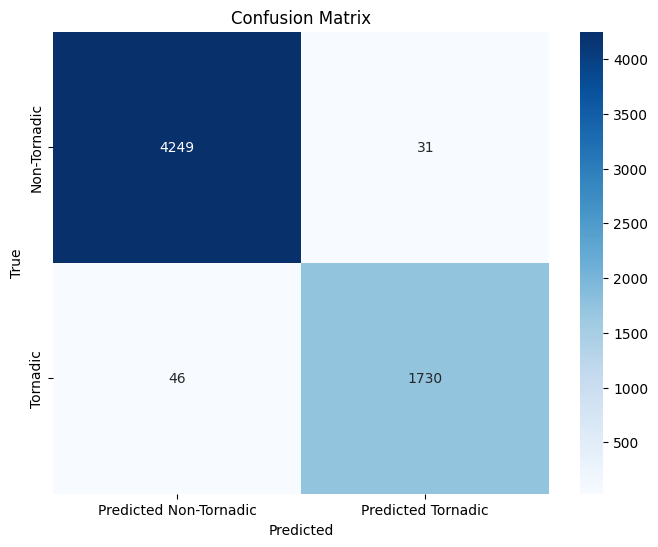

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Non-Tornadic', 'Predicted Tornadic'], yticklabels=['Non-Tornadic', 'Tornadic'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()